# Market Basket Analysis 

#### Importing Importanat Libraries

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from mlxtend.preprocessing import TransactionEncoder # OR...from mlxtend.preprocessing import OnehotTransactions
from mlxtend.frequent_patterns import apriori, association_rules

 Installing openpyxl for reading Excel Files in notebook

In [2]:
pip install openpyxl

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.3.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


#### Reading Files (.csv or .xlsx)

In [4]:
file_path = "Egyptian_Grocery_Transactions.xlsx"

if file_path.endswith(".csv"):
    df = pd.read_csv(file_path, header=None)
else:
    df = pd.read_excel(file_path, header=None)

df

,0
0,"سكر,لبن,شاي"
1,"فراخ,بطاطس"
2,"رز,فراخ"
3,"عسل,لحمة,رز,زبادي"
4,"بصل,رز,عدس"
5,"شيبسي,فلفل,بيبسي,مياه"
6,"فراخ,بطاطس,شيبسي"
7,"طماطم,عدس,كورن فليكس"
8,"عسل,مربة,زيت,عيش بلدي"
9,"فراخ,مكرونة,شاي,كشري,سكر,سمنة"


#### Making the only column of data called items
I renamed the column to items to make it easier to reference in the code instead of using a numeric column name. 

In [5]:
df.columns=['items']
df

,items
0,"سكر,لبن,شاي"
1,"فراخ,بطاطس"
2,"رز,فراخ"
3,"عسل,لحمة,رز,زبادي"
4,"بصل,رز,عدس"
5,"شيبسي,فلفل,بيبسي,مياه"
6,"فراخ,بطاطس,شيبسي"
7,"طماطم,عدس,كورن فليكس"
8,"عسل,مربة,زيت,عيش بلدي"
9,"فراخ,مكرونة,شاي,كشري,سكر,سمنة"


#### Converting it to array of list
I extracted the values from the items column to work with them as a list of transactions.

In [6]:
items=df['items'].values
items

<StringArray>
[                       'سكر,لبن,شاي',                         'فراخ,بطاطس',
                            'رز,فراخ',                  'عسل,لحمة,رز,زبادي',
                         'بصل,رز,عدس',              'شيبسي,فلفل,بيبسي,مياه',
                   'فراخ,بطاطس,شيبسي',               'طماطم,عدس,كورن فليكس',
              'عسل,مربة,زيت,عيش بلدي',      'فراخ,مكرونة,شاي,كشري,سكر,سمنة',
                            'عسل,عدس',  'زيت,بيض,فول,مكرونة,صلصة,جبنة قريش',
          'شاي,عدس,عسل,زيت,بيبسي,بيض',                        'رز,عدس,كشري',
                      'كشري,عيش بلدي',                     'لبن,بيبسي,مربة',
                'سكر,عيش بلدي,مكرونة',                  'بيبسي,زبادي,طعمية',
          'بيبسي,سكر,زيت,عدس,فول,بيض', 'بيض,بيبسي,طعمية,سكر,سمنة,جبنة قريش']
Length: 20, dtype: str

#### Transform items to list of list of items
- I created an empty list to store each transaction after splitting the items.
- Each row contains multiple items separated by commas, so I split them into individual items to represent each transaction as a list.
- I removed any extra whitespace around item names to make sure the items are clean and consistent for analysis.

In [7]:
transactions=[]

for i in range(0,len(items)):
    transactions.append(items[i].split(','))
transactions = [[item.strip() for item in t] for t in transactions] # To make sure that there isn't any whitespace
transactions

[['سكر', 'لبن', 'شاي'],
 ['فراخ', 'بطاطس'],
 ['رز', 'فراخ'],
 ['عسل', 'لحمة', 'رز', 'زبادي'],
 ['بصل', 'رز', 'عدس'],
 ['شيبسي', 'فلفل', 'بيبسي', 'مياه'],
 ['فراخ', 'بطاطس', 'شيبسي'],
 ['طماطم', 'عدس', 'كورن فليكس'],
 ['عسل', 'مربة', 'زيت', 'عيش بلدي'],
 ['فراخ', 'مكرونة', 'شاي', 'كشري', 'سكر', 'سمنة'],
 ['عسل', 'عدس'],
 ['زيت', 'بيض', 'فول', 'مكرونة', 'صلصة', 'جبنة قريش'],
 ['شاي', 'عدس', 'عسل', 'زيت', 'بيبسي', 'بيض'],
 ['رز', 'عدس', 'كشري'],
 ['كشري', 'عيش بلدي'],
 ['لبن', 'بيبسي', 'مربة'],
 ['سكر', 'عيش بلدي', 'مكرونة'],
 ['بيبسي', 'زبادي', 'طعمية'],
 ['بيبسي', 'سكر', 'زيت', 'عدس', 'فول', 'بيض'],
 ['بيض', 'بيبسي', 'طعمية', 'سكر', 'سمنة', 'جبنة قريش']]

#### Initialize TransactionEncoder and Convert transactions to one-hot encoding
- I used TransactionEncoder to convert the transaction data into a format suitable for association rule mining.
- This step transforms the transactions into one-hot encoded data, where each item becomes a column and values are True/False depending on whether the item appears in the transaction.

In [8]:
encoder=TransactionEncoder()
trans=encoder.fit_transform(transactions)
trans

array([[False, False, False, False, False, False, False, False,  True,
        False,  True, False, False, False, False, False, False, False,
        False, False, False, False, False,  True, False, False, False,
        False],
       [False,  True, False, False, False, False, False, False, False,
        False, False, False, False, False, False, False, False, False,
         True, False, False, False, False, False, False, False, False,
        False],
       [False, False, False, False, False,  True, False, False, False,
        False, False, False, False, False, False, False, False, False,
         True, False, False, False, False, False, False, False, False,
        False],
       [False, False, False, False, False,  True,  True, False, False,
        False, False, False, False, False, False, False,  True, False,
        False, False, False, False, False, False,  True, False, False,
        False],
       [ True, False, False, False, False,  True, False, False, False,
        False

#### Create encoded dataframe
I converted the encoded data into a DataFrame so it can be easily used by the Apriori algorithm.

In [9]:
encoded_data=pd.DataFrame(trans,columns=encoder.columns_,dtype=int)
encoded_data

,بصل,بطاطس,بيبسي,بيض,جبنة قريش,رز,زبادي,زيت,سكر,سمنة,...,فراخ,فلفل,فول,كشري,كورن فليكس,لبن,لحمة,مربة,مكرونة,مياه
0,0,0,0,0,0,0,0,0,1,0,...,0,0,0,0,0,1,0,0,0,0
1,0,1,0,0,0,0,0,0,0,0,...,1,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,1,0,0,0,0,...,1,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,1,1,0,0,0,...,0,0,0,0,0,0,1,0,0,0
4,1,0,0,0,0,1,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
5,0,0,1,0,0,0,0,0,0,0,...,0,1,0,0,0,0,0,0,0,1
6,0,1,0,0,0,0,0,0,0,0,...,1,0,0,0,0,0,0,0,0,0
7,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,1,0,0,0,0,0
8,0,0,0,0,0,0,0,1,0,0,...,0,0,0,0,0,0,0,1,0,0
9,0,0,0,0,0,0,0,0,1,1,...,1,0,0,1,0,0,0,0,1,0


#### Apply Apriori algorithm and Sort itemsets by support
- I used the Apriori algorithm to find frequent itemsets in the dataset with a minimum support threshold of 0.1
- I sorted the frequent itemsets by support to see which item combinations appear most frequently in the dataset.

In [10]:
frequent_itemsets=apriori(encoded_data,min_support=0.1,use_colnames=True)
frequent_itemsets.sort_values(by = 'support', ascending = False)


f:\ITI\Data Mining\Day 1\.venv\Lib\site-packages\mlxtend\frequent_patterns\fpcommon.py:175: DeprecationWarning: DataFrames with non-bool types result in worse computationalperformance and their support might be discontinued in the future.Please use a DataFrame with bool type
  warnings.warn(


,support,itemsets
1,0.30,frozenset({بيبسي})
12,0.30,frozenset({عدس})
7,0.25,frozenset({سكر})
6,0.20,frozenset({زيت})
13,0.20,frozenset({عسل})
2,0.20,frozenset({بيض})
4,0.20,frozenset({رز})
15,0.20,frozenset({فراخ})
14,0.15,frozenset({عيش بلدي})
17,0.15,frozenset({كشري})


#### Generate association rules and Sort rules by confidence
- I generated association rules from the frequent itemsets using confidence as the evaluation metric with a minimum threshold of 0.3
- I sorted the rules by confidence to identify the strongest associations between items.

In [11]:
rules=association_rules(frequent_itemsets,metric='confidence',min_threshold=0.3)
rules.sort_values('confidence',ascending=False)

,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,representativity,leverage,conviction,zhangs_metric,jaccard,certainty,kulczynski
0,frozenset({بطاطس}),frozenset({فراخ}),0.1,0.20,0.1,1.000000,5.000000,1.0,0.080,inf,0.888889,0.500000,1.000000,0.750000
21,frozenset({فول}),frozenset({بيض}),0.1,0.20,0.1,1.000000,5.000000,1.0,0.080,inf,0.888889,0.500000,1.000000,0.750000
13,frozenset({جبنة قريش}),frozenset({بيض}),0.1,0.20,0.1,1.000000,5.000000,1.0,0.080,inf,0.888889,0.500000,1.000000,0.750000
9,frozenset({طعمية}),frozenset({بيبسي}),0.1,0.30,0.1,1.000000,3.333333,1.0,0.070,inf,0.777778,0.333333,1.000000,0.666667
76,"frozenset({بيض, زيت, بيبسي})",frozenset({عدس}),0.1,0.30,0.1,1.000000,3.333333,1.0,0.070,inf,0.777778,0.333333,1.000000,0.666667
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
59,frozenset({عدس}),"frozenset({زيت, بيبسي})",0.3,0.10,0.1,0.333333,3.333333,1.0,0.070,1.350,1.000000,0.333333,0.259259,0.666667
66,frozenset({عدس}),"frozenset({بيض, زيت})",0.3,0.15,0.1,0.333333,2.222222,1.0,0.055,1.275,0.785714,0.285714,0.215686,0.500000
61,frozenset({بيبسي}),"frozenset({عدس, زيت})",0.3,0.10,0.1,0.333333,3.333333,1.0,0.070,1.350,1.000000,0.333333,0.259259,0.666667
85,frozenset({عدس}),"frozenset({بيض, زيت, بيبسي})",0.3,0.10,0.1,0.333333,3.333333,1.0,0.070,1.350,1.000000,0.333333,0.259259,0.666667


#### Saving rules and items as .csv files (If You want)

In [12]:
rules.to_csv("rules.csv", index=False)
frequent_itemsets.to_csv("items.csv", index=False)

#### Generating Top items to use them in visualization

In [21]:
frequent_itemsets['length'] = frequent_itemsets['itemsets'].apply(lambda x: len(x))
single_items = frequent_itemsets[frequent_itemsets['length'] == 1]
top_items = single_items.sort_values(by='support', ascending=True)

In [28]:
labels = top_items['itemsets'].astype(str)

Installing arabic-reshaper and python-bidi libraries to handle Arabic data

In [30]:
pip install arabic-reshaper

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.3.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [31]:
pip install python-bidi

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.3.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


#### Converting labels to arabic labels

In [39]:
import arabic_reshaper
from bidi.algorithm import get_display

arabic_labels = [
    get_display(arabic_reshaper.reshape(label))
    for label in labels
]

#### Cteating a bar chart of top items

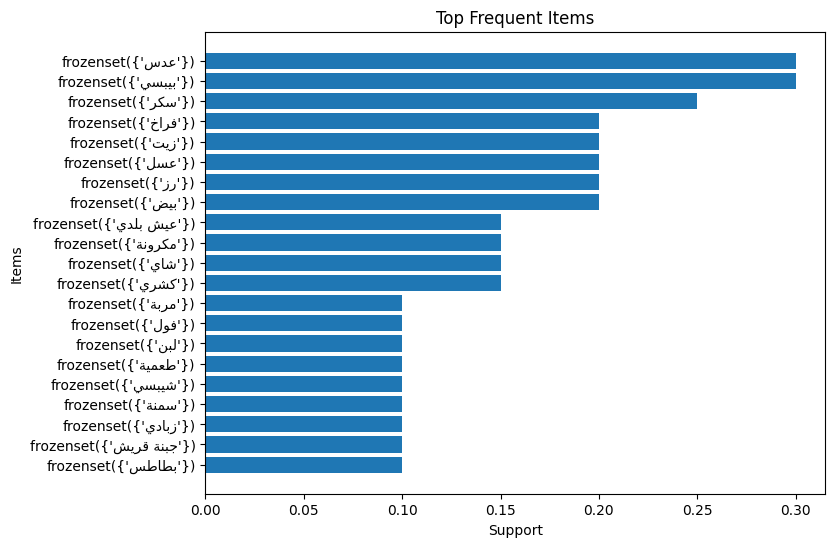

In [40]:
plt.figure(figsize=(8,6))

plt.barh(
    arabic_labels,
    top_items['support']
)

plt.xlabel("Support")
plt.ylabel("Items")
plt.title("Top Frequent Items")

plt.show()

Installing a networkx library to make a network diagram

In [23]:
pip install networkx

  Using cached networkx-3.6.1-py3-none-any.whl.metadata (6.8 kB)
Using cached networkx-3.6.1-py3-none-any.whl (2.1 MB)
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.3.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [42]:
def fix_arabic(text):
    return get_display(arabic_reshaper.reshape(text))

#### Making Network

In [43]:
import networkx as nx
strong_rules = rules[(rules['lift'] > 1.2) &
    (rules['confidence'] > 0.4)]

G = nx.DiGraph()

for _, row in strong_rules.iterrows():
    
    antecedent = list(row['antecedents'])[0]
    consequent = list(row['consequents'])[0]
    
    G.add_edge(
        fix_arabic(antecedent),
        fix_arabic(consequent)
    )

#### Making Diagram

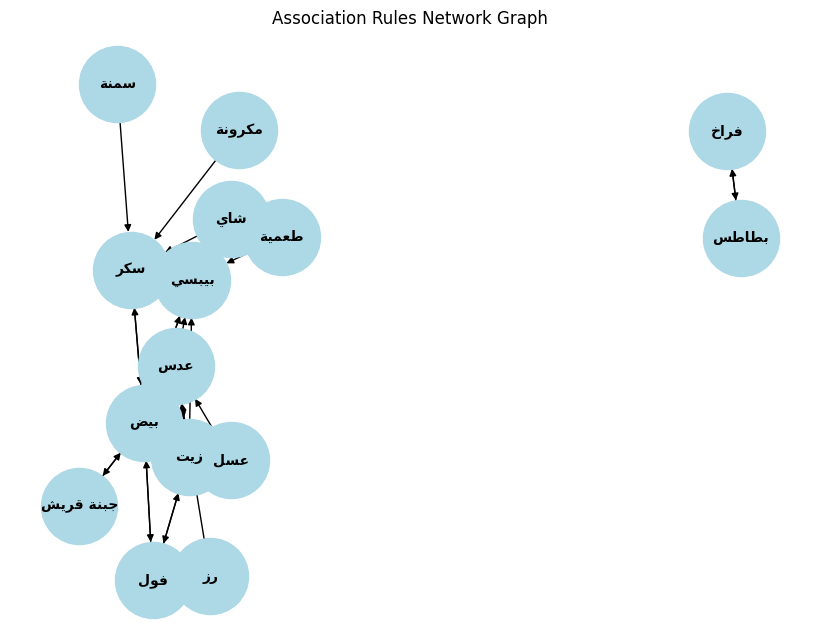

In [53]:
plt.figure(figsize=(8,6))

pos = nx.spring_layout(G)

nx.draw(
    G,
    pos,
    with_labels=True,
    node_size=3000,
    node_color="lightblue",
    font_size=10,
    font_weight="bold"
)

plt.title("Association Rules Network Graph")

plt.show()